In this file:
- RNA vs Protein - by ns and by abx
- Orthogonal Displacement from baseline
-- Numerical analysis

/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_30613/3436641729.py:168: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/aliceaznardejongh/miniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


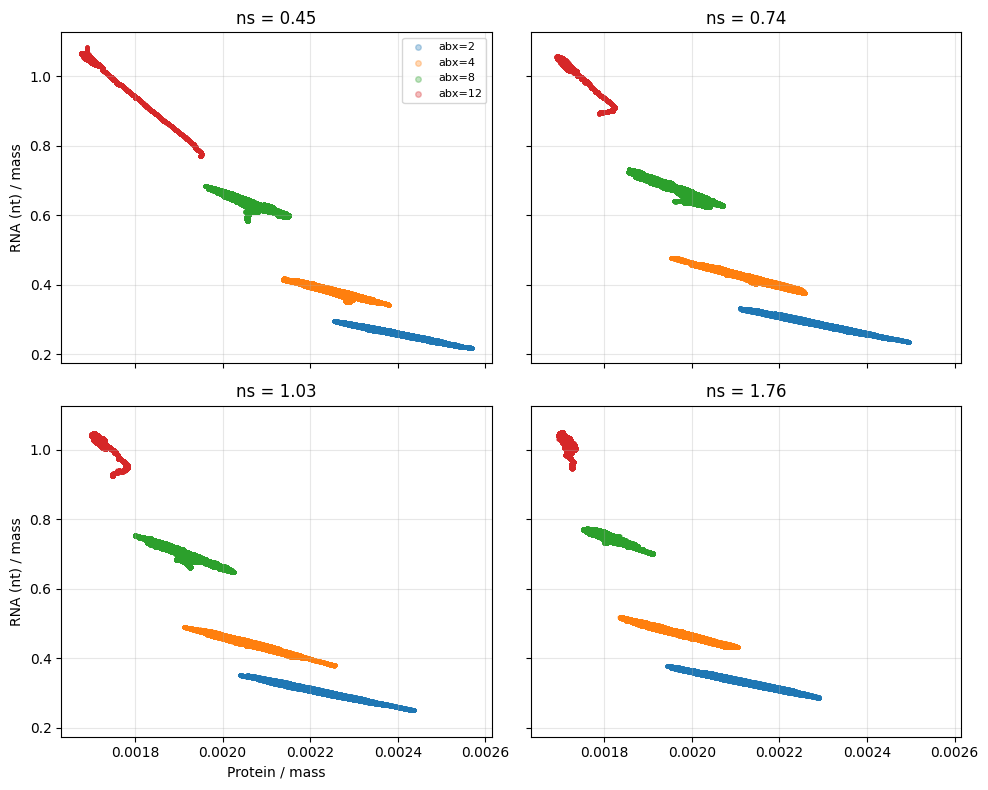

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Simulation files
# --------------------------------------------------------------
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45, 12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74, 12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03, 12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76, 12): "Data/ns176/abx12.arrow",
}


NR = 7549.0    # ribosomal protein size (AA)
NX = 300.0     # non-ribosomal protein size (AA)
BURN_IN = 1000.0

# --------------------------------------------------------------
# Correct mRNA lengths (AA)
# --------------------------------------------------------------
MRNA_LENGTHS_AA = {
    "mm": NX,
    "mt": NX,
    "mq": NX,
    "mr": NR
}

# Corrected rRNA length per ribosome
RIBO_RNA_NT = 4565

# Colormap
CMAP = plt.cm.plasma

# --------------------------------------------------------------
# Load Arrow
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# --------------------------------------------------------------
# Protein mass (simulation definition)
# --------------------------------------------------------------
def compute_protein(df):
    r   = df["r(t)"].to_numpy()
    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()


    return (r+q+et+em)

# --------------------------------------------------------------
# RNA nucleotide mass (correct)
# --------------------------------------------------------------
def compute_RNA_nt(df, mrna_lengths_aa, ribo_rna_nt=RIBO_RNA_NT):

    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    mm_nt = 3 * mrna_lengths_aa["mm"]
    mt_nt = 3 * mrna_lengths_aa["mt"]
    mq_nt = 3 * mrna_lengths_aa["mq"]
    mr_nt = 3 * mrna_lengths_aa["mr"]

    mRNA_mass = (
        mm_tot * mm_nt +
        mt_tot * mt_nt +
        mq_tot * mq_nt +
        mr_tot * mr_nt
    ).to_numpy()

    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * ribo_rna_nt

    return mRNA_mass + rRNA_mass

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)

    total_mass = ribo_mass + prot_mass
    return total_mass
# --------------------------------------------------------------
# Time-gradient plot
# --------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

ns_values = [0.45, 0.74, 1.03, 1.76]
abx_values = [2, 4, 8, 12]

for ax, ns in zip(axes, ns_values):

    for abx in abx_values:
        fn = FILES[(ns, abx)]
        df = load_arrow(fn)

        # burn-in
        df = df[df["timestamp"] >= BURN_IN]

        # OPTIONAL but recommended: clip RNA at zero
        for c in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

        total_mass = compute_mass(df)
        RNA = compute_RNA_nt(df, MRNA_LENGTHS_AA) / total_mass
        PROT = compute_protein(df) / total_mass

        ax.scatter(
            PROT,
            RNA,
            s=4,
            alpha=0.3,
            label=f"abx={abx}"
        )

    ax.set_title(f"ns = {ns}")
    ax.grid(alpha=0.3)

axes[2].set_xlabel("Protein / mass")
axes[0].set_ylabel("RNA (nt) / mass")
axes[2].set_ylabel("RNA (nt) / mass")

axes[0].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()



/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_24932/2905828863.py:155: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


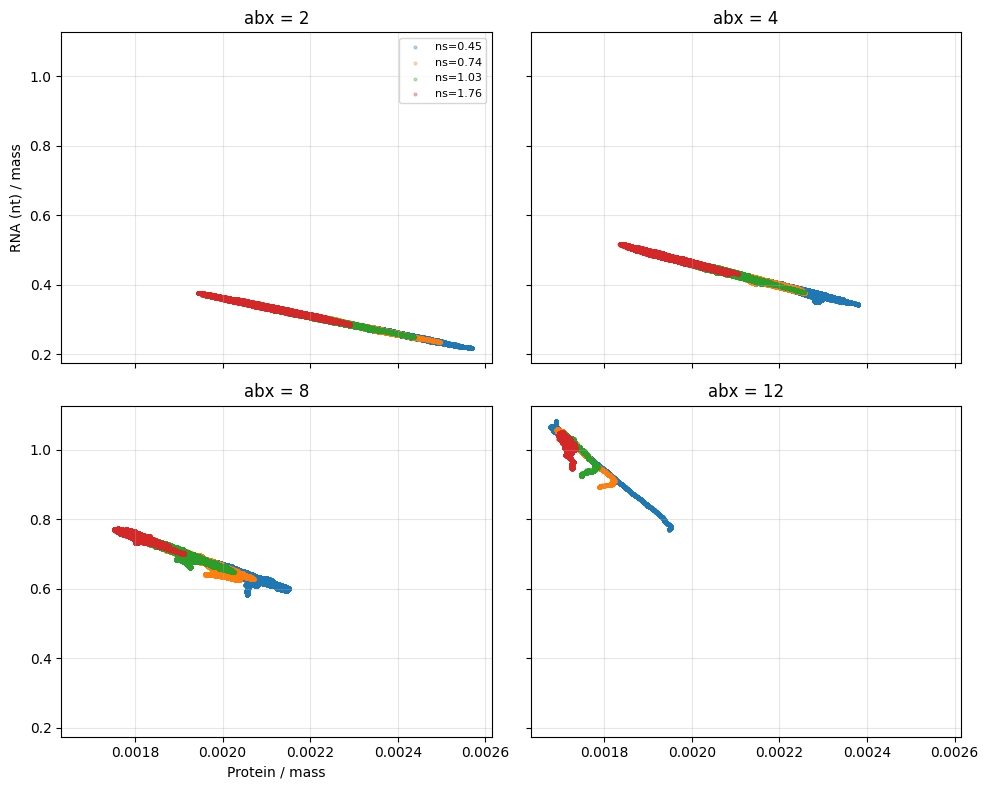

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Simulation files
# --------------------------------------------------------------
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45, 12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74, 12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03, 12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76, 12): "Data/ns176/abx12.arrow",
}


NR = 7549.0    # ribosomal protein size (AA)
NX = 300.0     # non-ribosomal protein size (AA)
BURN_IN = 1000.0

# --------------------------------------------------------------
# Correct mRNA lengths (AA)
# --------------------------------------------------------------
MRNA_LENGTHS_AA = {
    "mm": NX,
    "mt": NX,
    "mq": NX,
    "mr": NR
}

# Corrected rRNA length per ribosome
RIBO_RNA_NT = 4565

# Colormap
CMAP = plt.cm.plasma

# --------------------------------------------------------------
# Load Arrow
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# --------------------------------------------------------------
# Protein mass (simulation definition)
# --------------------------------------------------------------
def compute_protein(df):
    r   = df["r(t)"].to_numpy()
    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()


    return (r+q+et+em)

# --------------------------------------------------------------
# RNA nucleotide mass (correct)
# --------------------------------------------------------------
def compute_RNA_nt(df, mrna_lengths_aa, ribo_rna_nt=RIBO_RNA_NT):

    mm_tot = df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]
    mt_tot = df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]
    mq_tot = df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]
    mr_tot = df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]

    mm_nt = 3 * mrna_lengths_aa["mm"]
    mt_nt = 3 * mrna_lengths_aa["mt"]
    mq_nt = 3 * mrna_lengths_aa["mq"]
    mr_nt = 3 * mrna_lengths_aa["mr"]

    mRNA_mass = (
        mm_tot * mm_nt +
        mt_tot * mt_nt +
        mq_tot * mq_nt +
        mr_tot * mr_nt
    ).to_numpy()

    r_tot = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_mass = r_tot * ribo_rna_nt

    return mRNA_mass + rRNA_mass

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()

    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q  = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)

    total_mass = ribo_mass + prot_mass
    return total_mass
# --------------------------------------------------------------
# Time-gradient plot
# --------------------------------------------------------------

abx_values = [2, 4, 8, 12]
ns_values = [0.45, 0.74, 1.03, 1.76]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, abx in zip(axes, abx_values):

    for ns in ns_values:
        fn = FILES[(ns, abx)]
        df = load_arrow(fn)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_mass(df)
        RNA = compute_RNA_nt(df, MRNA_LENGTHS_AA) / total_mass
        PROT = compute_protein(df) / total_mass

        ax.scatter(PROT, RNA, s=4, alpha=0.3, label=f"ns={ns}")

    ax.set_title(f"abx = {abx}")
    ax.grid(alpha=0.3)

axes[2].set_xlabel("Protein / mass")
axes[0].set_ylabel("RNA (nt) / mass")
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()


Centroids / mean trajectories: Where does each condition sit in RNA–protein space on average?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Files: (ns, abx) → path
# --------------------------------------------------------------
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",
}
FILES0 = {
    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}

FILES_ALL = {}
FILES_ALL.update(FILES0)
FILES_ALL.update(FILES)   # abx = 2,4,8,12

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0

MRNA_LENGTHS_AA = {
    "mm": NX, "mt": NX, "mq": NX, "mr": NR
}

RIBO_RNA_NT = 4565
RNA_COLS = ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]

# --------------------------------------------------------------
# Helpers
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)
    return ribo_mass + prot_mass

def compute_protein_proxy(df):
    return (
        df["r(t)"].to_numpy() +
        df["q(t)"].to_numpy() +
        df["et(t)"].to_numpy() +
        df["em(t)"].to_numpy()
    )

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()


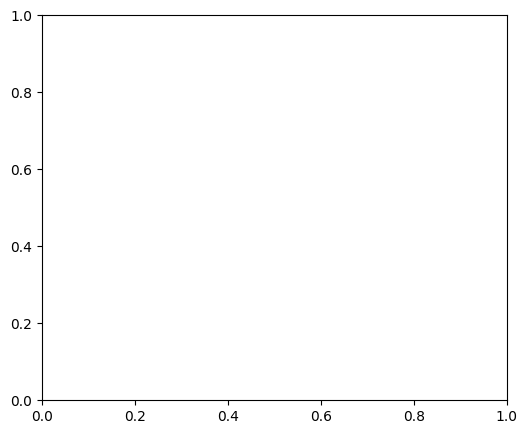

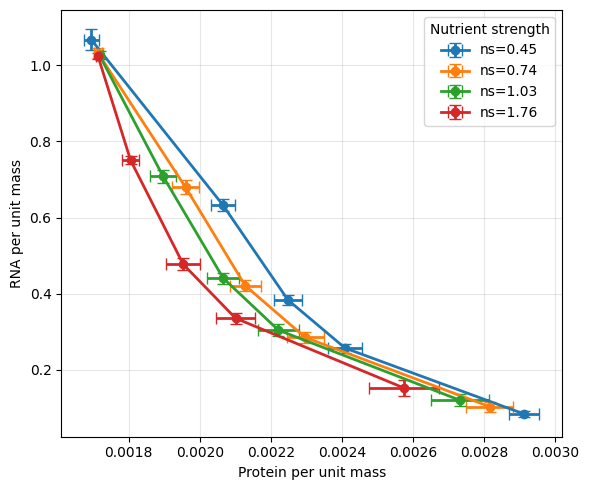

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --------------------------------------------------------------
# Files: (ns, abx) → path
# --------------------------------------------------------------
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",
}
FILES0 = {
    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}

FILES_ALL = {}
FILES_ALL.update(FILES0)
FILES_ALL.update(FILES)   # abx = 2,4,8,12

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0

MRNA_LENGTHS_AA = {
    "mm": NX, "mt": NX, "mq": NX, "mr": NR
}

RIBO_RNA_NT = 4565
RNA_COLS = ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]

# --------------------------------------------------------------
# Helpers
# --------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    prot_mass = NX * (q+et+em)
    return ribo_mass + prot_mass

def compute_protein_proxy(df):
    return (
        df["r(t)"].to_numpy() +
        df["q(t)"].to_numpy() +
        df["et(t)"].to_numpy() +
        df["em(t)"].to_numpy()
    )

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

# Centroids / mean trajectories
records = []

for (ns, abx), fn in FILES_ALL.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    # clip RNA
    for c in RNA_COLS:
        df[c] = np.maximum(df[c], 0.0)

    mass = compute_mass(df)
    RNA = compute_RNA_nt(df) / mass
    PROT = compute_protein_proxy(df) / mass

    records.append({
        "ns": ns,
        "abx": abx,
        "RNA_mean": RNA.mean(),
        "PROT_mean": PROT.mean(),
        "RNA_std": RNA.std(),
        "PROT_std": PROT.std(),
    })

res = pd.DataFrame(records)

# ---- Plot: fixed ns, abx varies ----
fig, ax = plt.subplots(figsize=(6,5))

fig, ax = plt.subplots(figsize=(6,5))

for ns, g in res.groupby("ns"):
    g = g.sort_values("abx")

    ax.errorbar(
        g["PROT_mean"],
        g["RNA_mean"],
        xerr=g["PROT_std"],   # ← horizontal error bars
        yerr=g["RNA_std"],    # ← vertical error bars
        fmt="-o",
        capsize=4,
        lw=2,
        label=f"ns={ns}"
    )


ax.set_xlabel("Protein per unit mass")
ax.set_ylabel("RNA per unit mass")
ax.legend(title="Nutrient strength")
ax.grid(alpha=0.3)
# ax.set_xlim(left=0)
# ax.set_ylim(bottom=0)


plt.tight_layout()
plt.show()



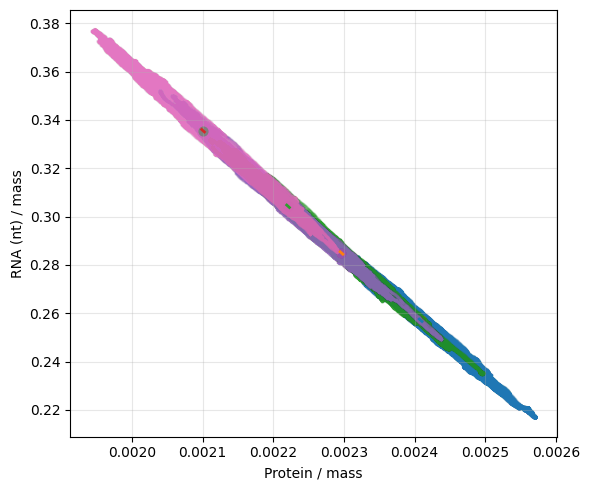

In [13]:
# Envelopes + principal direction
fig, ax = plt.subplots(figsize=(6,5))

for (ns, abx), fn in FILES.items():
    if abx != 2:  # choose baseline or any condition
        continue

    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    for c in RNA_COLS:
        df[c] = np.maximum(df[c], 0.0)

    mass = compute_mass(df)
    X = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])

    # scatter (faint)
    ax.scatter(X[:,0], X[:,1], s=3, alpha=0.05)

    # PCA
    mu = X.mean(axis=0)
    C = np.cov(X.T)
    eigvals, eigvecs = np.linalg.eigh(C)
    v = eigvecs[:, np.argmax(eigvals)]

    t = np.linspace(-0.0005, 0.0005, 200)
    line = mu + np.outer(t, v)

    ax.plot(line[:,0], line[:,1], lw=2)
    ax.scatter(mu[0], mu[1], s=40)

ax.set_xlabel("Protein / mass")
ax.set_ylabel("RNA (nt) / mass")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


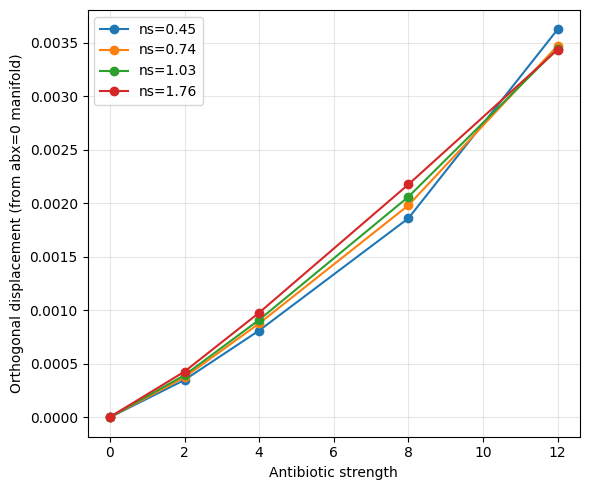

In [16]:
# --------------------------------------------------------------
# 1. Build baseline manifold (abx=0)
# --------------------------------------------------------------
X_base = []
FILES0 = {
    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}

for (ns, abx), fn in FILES0.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    # clip RNA in baseline too
    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    mass = compute_mass(df)
    X = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])
    X_base.append(X)

X_base = np.vstack(X_base)
mu0 = X_base.mean(axis=0)

C0 = np.cov(X_base.T)
eigvals, eigvecs = np.linalg.eigh(C0)
vhat = eigvecs[:, np.argmax(eigvals)]
vhat /= np.linalg.norm(vhat)

# --------------------------------------------------------------
# 2. Measure orthogonal displacement (include abx=0 too)
# --------------------------------------------------------------
disp = []

FILES_ALL = {}
FILES_ALL.update(FILES0)
FILES_ALL.update(FILES)

for (ns, abx), fn in FILES_ALL.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    mass = compute_mass(df)
    X = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])

    delta = X - mu0
    parallel = delta @ vhat
    orth = np.linalg.norm(delta - np.outer(parallel, vhat), axis=1)

    disp.append({
        "ns": ns,
        "abx": abx,
        "orth_disp": orth.mean()
    })

disp = pd.DataFrame(disp)

# --------------------------------------------------------------
# 3. Plot displacement vs antibiotic (now includes abx=0)
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

for ns, g in disp.groupby("ns"):
    g = g.sort_values("abx")
    ax.plot(g["abx"], g["orth_disp"], "-o", label=f"ns={ns}")

ax.set_xlabel("Antibiotic strength")
ax.set_ylabel("Orthogonal displacement (from abx=0 manifold)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


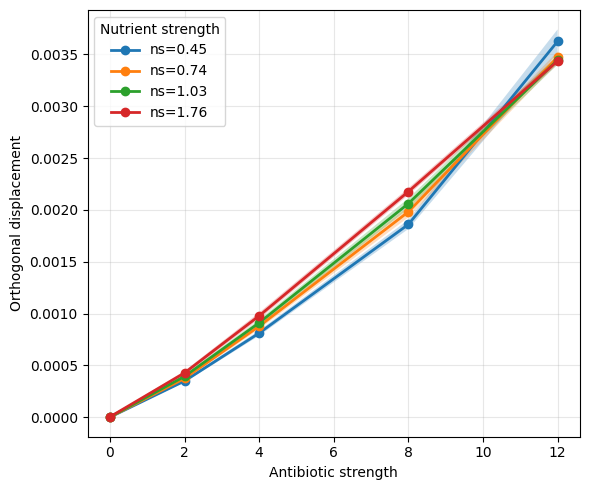

In [7]:
# ==============================================================
# METHOD 1: Per-sample orthogonal displacement (orth_std)
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. Build baseline manifold (abx = 0)
# --------------------------------------------------------------
X_base = []

for (ns, abx), fn in FILES0.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    mass = compute_mass(df)
    X = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])
    X_base.append(X)

X_base = np.vstack(X_base)

mu0 = X_base.mean(axis=0)
C0 = np.cov(X_base.T)

eigvals, eigvecs = np.linalg.eigh(C0)
vhat = eigvecs[:, np.argmax(eigvals)]
vhat /= np.linalg.norm(vhat)

# --------------------------------------------------------------
# 2. Orthogonal displacement per condition
# --------------------------------------------------------------
disp = []

for (ns, abx), fn in FILES_ALL.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    mass = compute_mass(df)
    X = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])

    delta = X - mu0
    parallel = delta @ vhat
    orth = np.linalg.norm(delta - np.outer(parallel, vhat), axis=1)

    disp.append({
        "ns": ns,
        "abx": abx,
        "orth_mean": orth.mean(),
        "orth_std": orth.std(ddof=1),
        "n": len(orth),
    })

disp = pd.DataFrame(disp)

# --------------------------------------------------------------
# Plot displacement vs antibiotic (error shadow)
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6,5))

for ns, g in disp.groupby("ns"):
    g = g.sort_values("abx")

    x = g["abx"].to_numpy()
    y = g["orth_mean"].to_numpy()
    e = g["orth_std"].to_numpy()

    ax.plot(x, y, "-o", lw=2, label=f"ns={ns}")
    ax.fill_between(
        x,
        y - e,
        y + e,
        alpha=0.25
    )

ax.set_xlabel("Antibiotic strength")
ax.set_ylabel("Orthogonal displacement")
ax.legend(title="Nutrient strength")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



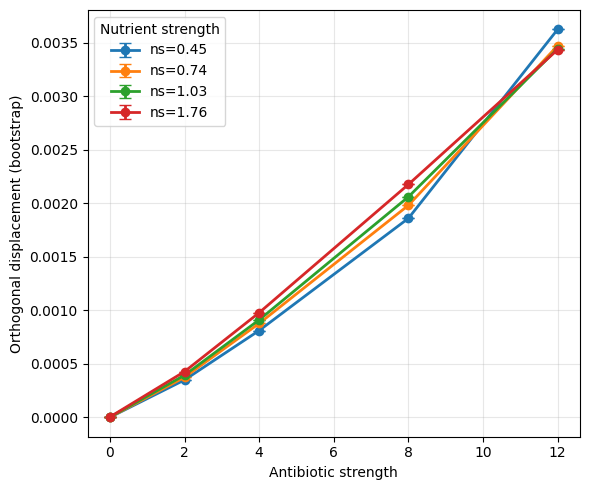

In [6]:
# ==============================================================
# METHOD 2: Bootstrap baseline + condition clouds
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
B = 300  # number of bootstrap replicates

# --------------------------------------------------------------
# 1. Preload baseline clouds
# --------------------------------------------------------------
BASE_CLOUDS = {}

for (ns, abx), fn in FILES0.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    mass = compute_mass(df)
    BASE_CLOUDS[ns] = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])

# --------------------------------------------------------------
# 2. Preload all condition clouds (including abx=0)
# --------------------------------------------------------------
COND_CLOUDS = {}

for (ns, abx), fn in FILES_ALL.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    for c in RNA_COLS:
        if c in df.columns:
            df[c] = np.maximum(df[c].to_numpy(), 0.0)

    mass = compute_mass(df)
    COND_CLOUDS[(ns, abx)] = np.column_stack([
        compute_protein_proxy(df) / mass,
        compute_RNA_nt(df) / mass
    ])

# --------------------------------------------------------------
# 3. Bootstrap loop
# --------------------------------------------------------------
boot_records = []

for b in range(B):
    # ---- bootstrap baseline ----
    Xb = []
    for X in BASE_CLOUDS.values():
        idx = rng.integers(0, len(X), len(X))
        Xb.append(X[idx])
    Xb = np.vstack(Xb)

    mu0_b = Xb.mean(axis=0)
    Cb = np.cov(Xb.T)

    eigvals, eigvecs = np.linalg.eigh(Cb)
    vhat_b = eigvecs[:, np.argmax(eigvals)]
    vhat_b /= np.linalg.norm(vhat_b)

    # ---- bootstrap each condition ----
    for (ns, abx), X in COND_CLOUDS.items():
        idx = rng.integers(0, len(X), len(X))
        Xr = X[idx]

        delta = Xr - mu0_b
        parallel = delta @ vhat_b
        orth = np.linalg.norm(delta - np.outer(parallel, vhat_b), axis=1)

        boot_records.append({
            "boot": b,
            "ns": ns,
            "abx": abx,
            "orth_mean": orth.mean()
        })

boot = pd.DataFrame(boot_records)

# --------------------------------------------------------------
# 4. Aggregate bootstrap statistics
# --------------------------------------------------------------
disp_boot = (
    boot
    .groupby(["ns", "abx"])
    .agg(
        orth_mean=("orth_mean", "mean"),
        orth_std=("orth_mean", "std")
    )
    .reset_index()
)

# --------------------------------------------------------------
# 5. Plot bootstrap displacement
# --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6,5))

for ns, g in disp_boot.groupby("ns"):
    g = g.sort_values("abx")
    ax.errorbar(
        g["abx"],
        g["orth_mean"],
        yerr=g["orth_std"],
        fmt="-o",
        lw=2,
        capsize=4,
        label=f"ns={ns}"
    )

ax.set_xlabel("Antibiotic strength")
ax.set_ylabel("Orthogonal displacement (bootstrap)")
ax.legend(title="Nutrient strength")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# baseline per ns
base = disp[disp["abx"] == 0][["ns", "orth_disp"]].rename(columns={"orth_disp": "d0"})

# merge baseline into all rows
disp2 = disp.merge(base, on="ns", how="left")

# absolute and relative changes
disp2["delta_d"] = disp2["orth_disp"] - disp2["d0"]
disp2["fold_change"] = disp2["orth_disp"] / disp2["d0"]
disp2["pct_change"] = 100 * disp2["delta_d"] / disp2["d0"]

# optional stabilized log fold-change
eps = 1e-6
disp2["log_fc"] = np.log((disp2["orth_disp"] + eps) / (disp2["d0"] + eps))

# summary table: one row per (ns, abx)
summary = disp2.sort_values(["ns", "abx"])
print(summary[["ns", "abx", "orth_disp", "d0", "delta_d", "fold_change", "pct_change"]])


      ns  abx  orth_disp        d0   delta_d  fold_change     pct_change
0   0.45    0   0.000001  0.000001  0.000000     1.000000       0.000000
4   0.45    2   0.000350  0.000001  0.000349   256.544208   25554.420774
5   0.45    4   0.000812  0.000001  0.000811   594.492339   59349.233923
6   0.45    8   0.001860  0.000001  0.001859  1361.629481  136062.948138
7   0.45   12   0.003625  0.000001  0.003624  2653.319319  265231.931891
1   0.74    0   0.000002  0.000002  0.000000     1.000000       0.000000
8   0.74    2   0.000376  0.000002  0.000374   192.375639   19137.563945
9   0.74    4   0.000878  0.000002  0.000876   449.837813   44883.781316
10  0.74    8   0.001982  0.000002  0.001980  1015.036959  101403.695916
11  0.74   12   0.003472  0.000002  0.003471  1778.702738  177770.273778
2   1.03    0   0.000003  0.000003  0.000000     1.000000       0.000000
12  1.03    2   0.000395  0.000003  0.000392   140.030534   13903.053450
13  1.03    4   0.000912  0.000003  0.000909   323.

In [18]:
from numpy.linalg import lstsq

rows = []
for ns, g in disp2.groupby("ns"):
    g = g.sort_values("abx")
    x = g["abx"].to_numpy()
    y = g["orth_disp"].to_numpy()
    A = np.column_stack([np.ones_like(x), x])
    a, b = lstsq(A, y, rcond=None)[0]  # y ≈ a + b x

    # R^2
    yhat = a + b*x
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2) + 1e-12
    r2 = 1 - ss_res/ss_tot

    rows.append({"ns": ns, "slope_b": b, "intercept_a": a, "R2": r2})

slopes = pd.DataFrame(rows)
print(slopes)


     ns   slope_b  intercept_a        R2
0  0.45  0.000299    -0.000225  0.971937
1  0.74  0.000290    -0.000165  0.987593
2  1.03  0.000289    -0.000140  0.992432
3  1.76  0.000290    -0.000102  0.996782


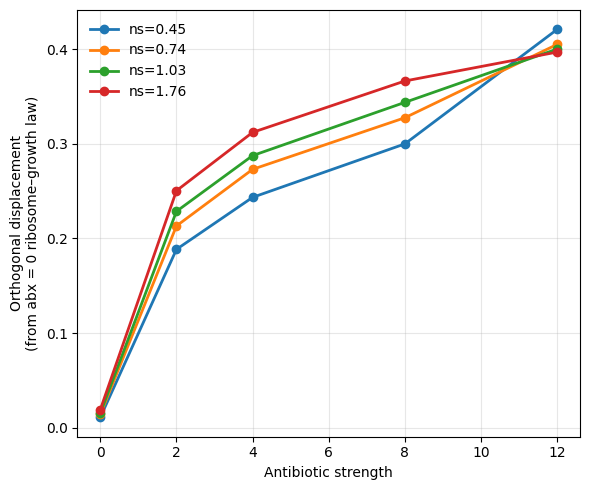

,ns,abx,orth_disp
0,0.45,0,0.010836
4,0.45,2,0.188448
5,0.45,4,0.243447
6,0.45,8,0.299971
7,0.45,12,0.421035
1,0.74,0,0.013960
8,0.74,2,0.213214
9,0.74,4,0.273066
10,0.74,8,0.327617
11,0.74,12,0.405165


In [8]:
# ============================================================
# Orthogonal displacement in (growth rate λ, ribosomal mass φR)
# Relative to abx = 0 ribosome–growth manifold
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

# Antibiotic-free baseline files
FILES0 = {
    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",
}

# All conditions (must include abx > 0)
# FILES = {(ns, abx): "path/to/file.arrow", ...}

# ------------------------------------------------------------
# I/O
# ------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# MODEL DEFINITIONS (UNCHANGED)
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma

# ------------------------------------------------------------
# 1. BUILD BASELINE MANIFOLD (abx = 0)
# ------------------------------------------------------------
X_base = []

for (ns, abx), fn in FILES0.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    ribo_mass, mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)

    lam = (ttrate / mass) * 60.0     # 1/hour
    phiR = ribo_mass / mass

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    X = np.column_stack([lam[valid], phiR[valid]])
    X_base.append(X)

X_base = np.vstack(X_base)

# Mean point of baseline manifold
mu0 = X_base.mean(axis=0)

# PCA direction = ribosome–growth law
C0 = np.cov(X_base.T)
eigvals, eigvecs = np.linalg.eigh(C0)
vhat = eigvecs[:, np.argmax(eigvals)]
vhat /= np.linalg.norm(vhat)

# ------------------------------------------------------------
# 2. MEASURE ORTHOGONAL DISPLACEMENT (all abx)
# ------------------------------------------------------------
disp = []

FILES_ALL = {}
FILES_ALL.update(FILES0)
FILES_ALL.update(FILES)

for (ns, abx), fn in FILES_ALL.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    ribo_mass, mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)

    lam = (ttrate / mass) * 60.0
    phiR = ribo_mass / mass

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    X = np.column_stack([lam[valid], phiR[valid]])

    delta = X - mu0
    parallel = delta @ vhat
    orth = np.linalg.norm(delta - np.outer(parallel, vhat), axis=1)

    disp.append({
        "ns": ns,
        "abx": abx,
        "orth_disp": orth.mean()
    })

disp = pd.DataFrame(disp)

# ------------------------------------------------------------
# 3. PLOT: ORTHOGONAL DISPLACEMENT VS ANTIBIOTIC
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

for ns, g in disp.groupby("ns"):
    g = g.sort_values("abx")
    ax.plot(
        g["abx"],
        g["orth_disp"],
        "-o",
        lw=2,
        label=f"ns={ns:.2f}"
    )

ax.set_xlabel("Antibiotic strength")
ax.set_ylabel("Orthogonal displacement\n(from abx = 0 ribosome–growth law)")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DEBUG TABLE
# ------------------------------------------------------------
display(disp.sort_values(["ns", "abx"]))


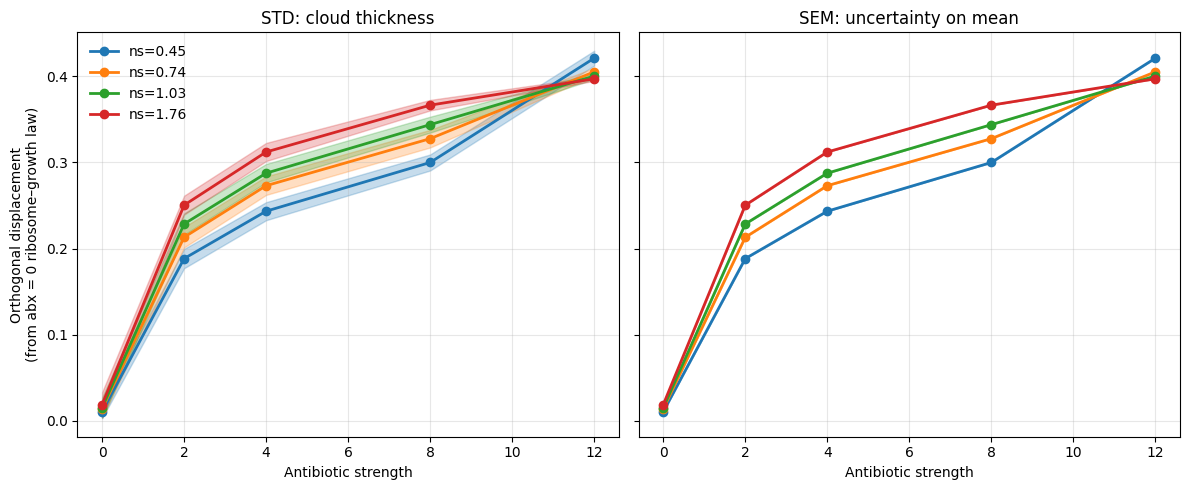

,ns,abx,orth_mean,orth_std,n
0,0.45,0,0.010836,0.007773,305226
1,0.74,0,0.013960,0.010140,215594
2,1.03,0,0.015375,0.011717,175813
3,1.76,0,0.019002,0.014313,131556
4,0.45,2,0.188448,0.011193,991755
5,0.45,4,0.243447,0.010463,991281
6,0.45,8,0.299971,0.009291,990917
7,0.45,12,0.421035,0.008634,990165
8,0.74,2,0.213214,0.011842,861085
9,0.74,4,0.273066,0.010739,991683


In [16]:

# ============================================================
# Orthogonal displacement in (growth rate λ, ribosomal mass φR)
# Relative to abx = 0 ribosome–growth manifold
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0  # minutes

# Antibiotic-free baseline files
FILES0 = {
    (0.45, 0): "Data/ns045.arrow",
    (0.74, 0): "Data/ns074.arrow",
    (1.03, 0): "Data/ns103.arrow",
    (1.76, 0): "Data/ns176.arrow",
}
FILES = {
    (0.45, 2): "Data/ns045/abx2.arrow",
    (0.45, 4): "Data/ns045/abx4.arrow",
    (0.45, 8): "Data/ns045/abx8.arrow",
    (0.45,12): "Data/ns045/abx12.arrow",

    (0.74, 2): "Data/ns074/abx2.arrow",
    (0.74, 4): "Data/ns074/abx4.arrow",
    (0.74, 8): "Data/ns074/abx8.arrow",
    (0.74,12): "Data/ns074/abx12.arrow",

    (1.03, 2): "Data/ns103/abx2.arrow",
    (1.03, 4): "Data/ns103/abx4.arrow",
    (1.03, 8): "Data/ns103/abx8.arrow",
    (1.03,12): "Data/ns103/abx12.arrow",

    (1.76, 2): "Data/ns176/abx2.arrow",
    (1.76, 4): "Data/ns176/abx4.arrow",
    (1.76, 8): "Data/ns176/abx8.arrow",
    (1.76,12): "Data/ns176/abx12.arrow",
}

# All conditions (must include abx > 0)
# FILES = {(ns, abx): "path/to/file.arrow", ...}

# ------------------------------------------------------------
# I/O
# ------------------------------------------------------------
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# MODEL DEFINITIONS (UNCHANGED)
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma

# ------------------------------------------------------------
# 1. BUILD BASELINE MANIFOLD (abx = 0)
# ------------------------------------------------------------
X_base = []

for (ns, abx), fn in FILES0.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    ribo_mass, mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)

    lam = (ttrate / mass) * 60.0     # 1/hour
    phiR = ribo_mass / mass

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    X = np.column_stack([lam[valid], phiR[valid]])
    X_base.append(X)

X_base = np.vstack(X_base)

# Mean point of baseline manifold
mu0 = X_base.mean(axis=0)

# PCA direction = ribosome–growth law
C0 = np.cov(X_base.T)
eigvals, eigvecs = np.linalg.eigh(C0)
vhat = eigvecs[:, np.argmax(eigvals)]
vhat /= np.linalg.norm(vhat)

# ------------------------------------------------------------
# 2. MEASURE ORTHOGONAL DISPLACEMENT (all abx)
# ------------------------------------------------------------
disp = []

FILES_ALL = {}
FILES_ALL.update(FILES0)
FILES_ALL.update(FILES)

for (ns, abx), fn in FILES_ALL.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    ribo_mass, mass = compute_mass(df)
    ttrate = compute_ttrate(df, mass)

    lam = (ttrate / mass) * 60.0
    phiR = ribo_mass / mass

    valid = (~np.isnan(lam)) & (~np.isnan(phiR))
    X = np.column_stack([lam[valid], phiR[valid]])

    delta = X - mu0
    parallel = delta @ vhat
    orth = np.linalg.norm(delta - np.outer(parallel, vhat), axis=1)

    disp.append({
    "ns": ns,
    "abx": abx,
    "orth_mean": orth.mean(),
    "orth_std": orth.std(ddof=1),
    "n": len(orth),
})


disp = pd.DataFrame(disp)
# ------------------------------------------------------------
# SIDE-BY-SIDE PLOTS: STD vs SEM SHADOWS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ============================
# LEFT: STD (cloud thickness)
# ============================
ax = axes[0]

for ns, g in disp.groupby("ns"):
    g = g.sort_values("abx")

    x = g["abx"].to_numpy()
    y = g["orth_mean"].to_numpy()
    e = g["orth_std"].to_numpy()

    line, = ax.plot(
        x, y, "-o", lw=2, label=f"ns={ns:.2f}"
    )
    ax.fill_between(
        x, y - e, y + e,
        color=line.get_color(),
        alpha=0.25
    )

ax.set_title("STD: cloud thickness")
ax.set_xlabel("Antibiotic strength")
ax.set_ylabel("Orthogonal displacement\n(from abx = 0 ribosome–growth law)")
ax.grid(alpha=0.3)
ax.legend(frameon=False)

# ============================
# RIGHT: SEM (mean uncertainty)
# ============================
ax = axes[1]

for ns, g in disp.groupby("ns"):
    g = g.sort_values("abx")

    x = g["abx"].to_numpy()
    y = g["orth_mean"].to_numpy()
    e = g["orth_std"].to_numpy() / np.sqrt(g["n"].to_numpy())

    line, = ax.plot(
        x, y, "-o", lw=2, label=f"ns={ns:.2f}"
    )
    ax.fill_between(
        x, y - e, y + e,
        color=line.get_color(),
        alpha=0.25
    )

ax.set_title("SEM: uncertainty on mean")
ax.set_xlabel("Antibiotic strength")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
display(disp)


Left: Shaded bands show the standard deviation of orthogonal distances across post–burn-in timepoints, reflecting the intrinsic width of the trajectory cloud off the baseline manifold.
Right: Shaded bands show the standard error of the mean displacement, indicating the precision with which the mean off-manifold displacement is estimated.
